# Volume da aorta e qualidade visual da segmentação

## Objetivo

Analisa a quantidade de voxels da máscara final da aorta, sua ocupação percentual no volume processado e a área média por fatia. A análise usa rótulos visuais independentes para os conjuntos de treino e validação, relacionando a qualidade da aorta com a localização dos óstios e o Dice arterial.

O corte exploratório é estimado somente no treino e aplicado sem recalibração na validação.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Localiza a raiz antes dos imports internos quando o notebook abre em src/eda.
current = Path.cwd().resolve()
REPO_ROOT = next(
    path
    for path in [current, *current.parents]
    if (path / "src").exists() and (path / "output").exists()
)
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils.comparison_utils.io import load_split_summary  # noqa: E402
from utils.project.notebook_env import configure_notebook_environment  # noqa: E402

REPO_ROOT = configure_notebook_environment(chdir_to_src=False)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Configuração

Os rótulos visuais abaixo foram definidos após inspeção dos HTMLs 3D de cada run. `both correct` e `both tolerable` são considerados sucesso dos óstios.

As tabelas de treino e validação são mantidas separadas. O exame 187 é classificado como aorta boa, com a observação de que poderia ser segmentado um pouco mais.

In [2]:
TRAIN_RUN_DIR = (
    REPO_ROOT
    / "output/segmentation/runs/mid_res/2026-08-22_08-11-56"
)
VAL_RUN_DIR = (
    REPO_ROOT
    / "output/segmentation/runs/mid_res/2026-08-22_09-27-56"
)

TRAIN_GOOD_AORTA_IDS = {
    13, 28, 90, 129, 194, 305, 344, 380, 428, 447, 518, 538,
    550, 631, 676, 696, 752, 793, 836, 854, 887, 937, 965,
}
TRAIN_BAD_AORTA_IDS = {44, 175, 315, 330, 603, 608, 760}

VAL_GOOD_AORTA_IDS = {
    2, 6, 35, 89, 110, 116, 156, 187, 227, 294, 308, 341,
    384, 437, 444, 449, 450, 468, 490, 510, 513, 545, 552,
    570, 614, 656, 672, 705, 730, 737, 772, 802, 805, 810,
    813, 821, 832, 835, 870, 873, 881, 886, 913, 961, 978,
}
VAL_BAD_AORTA_IDS = {
    11, 134, 184, 296, 307, 464, 507, 597, 602, 720, 776,
    790, 792, 838, 907,
}
VAL_REVIEW_NOTES = {
    187: "boa; poderia segmentar um pouco mais",
}

print(f"Treino: {len(TRAIN_GOOD_AORTA_IDS)} boas e {len(TRAIN_BAD_AORTA_IDS)} ruins")
print(f"Validação: {len(VAL_GOOD_AORTA_IDS)} boas e {len(VAL_BAD_AORTA_IDS)} ruins")

Treino: 23 boas e 7 ruins
Validação: 45 boas e 15 ruins


## Carregamento e métricas derivadas

In [3]:
REQUIRED_COLUMNS = {
    "IMG_ID",
    "artery_dice",
    "ostia_detection_status",
    "aorta_mask_voxel_count",
    "aorta_segmented_slice_count",
    "aorta_voxels_per_segmented_slice",
    "aorta_volume_fraction",
}


def load_labeled_cohort(run_dir, split, good_ids, bad_ids, review_notes=None):
    """Carrega uma run e acrescenta os rótulos da inspeção visual."""
    numeric_dir = run_dir / "numeric"
    summary_path = numeric_dir / f"ostios_{split}_summary.csv"
    if not summary_path.is_file():
        raise FileNotFoundError(f"Resumo não encontrado: {summary_path}")

    split_paths = {"mid_res": {split: numeric_dir}}
    cohort_df = load_split_summary(split_paths, "mid_res", split)
    if cohort_df is None:
        raise RuntimeError(f"Não foi possível carregar o summary de {split}.")

    missing_columns = REQUIRED_COLUMNS.difference(cohort_df.columns)
    if missing_columns:
        raise ValueError(f"Colunas ausentes no summary: {sorted(missing_columns)}")

    cohort_df = cohort_df.copy()
    cohort_df["IMG_ID"] = pd.to_numeric(
        cohort_df["IMG_ID"], errors="raise"
    ).astype(int)

    expected_ids = set(good_ids) | set(bad_ids)
    observed_ids = set(cohort_df["IMG_ID"])
    missing_ids = expected_ids.difference(observed_ids)
    unexpected_ids = observed_ids.difference(expected_ids)
    if missing_ids or unexpected_ids:
        raise ValueError(
            f"IDs incompatíveis em {split}. Ausentes={sorted(missing_ids)}; "
            f"não classificados={sorted(unexpected_ids)}"
        )

    # Deriva métricas legíveis e os desfechos usados nas tabelas.
    cohort_df["aorta_volume_percentage"] = (
        cohort_df["aorta_volume_fraction"] * 100.0
    )
    cohort_df["visual_aorta_quality"] = np.where(
        cohort_df["IMG_ID"].isin(good_ids),
        "boa",
        "ruim",
    )
    notes = review_notes or {}
    cohort_df["visual_review_note"] = cohort_df["IMG_ID"].map(notes).fillna("")

    normalized_status = cohort_df["ostia_detection_status"].astype(str).str.lower()
    cohort_df["ostia_success"] = normalized_status.isin(
        {"both correct", "both tolerable"}
    )
    cohort_df["ostia_outcome"] = np.where(
        cohort_df["ostia_success"],
        "sucesso",
        "falha",
    )
    cohort_df["max_ostium_distance_mm"] = cohort_df[
        ["left_ostium_distance_mm", "right_ostium_distance_mm"]
    ].max(axis=1)
    return cohort_df


train_df = load_labeled_cohort(
    TRAIN_RUN_DIR,
    "train",
    TRAIN_GOOD_AORTA_IDS,
    TRAIN_BAD_AORTA_IDS,
)
val_df = load_labeled_cohort(
    VAL_RUN_DIR,
    "val",
    VAL_GOOD_AORTA_IDS,
    VAL_BAD_AORTA_IDS,
    VAL_REVIEW_NOTES,
)

# Mantém o nome curto usado na primeira parte do notebook.
df = train_df
print(f"Treino carregado: {len(train_df)} imagens")
print(f"Validação carregada: {len(val_df)} imagens")

Treino carregado: 30 imagens
Validação carregada: 60 imagens


## Funções de análise

Os helpers abaixo garantem que treino e validação usem exatamente as mesmas agregações e configurações visuais.

In [4]:
def build_overview_row(cohort_df, cohort_name):
    """Resume a escala geral das máscaras de uma coorte."""
    return {
        "coorte": cohort_name,
        "imagens": len(cohort_df),
        "voxels_aorta_media": cohort_df["aorta_mask_voxel_count"].mean(),
        "voxels_aorta_mediana": cohort_df["aorta_mask_voxel_count"].median(),
        "fatias_segmentadas_media": cohort_df[
            "aorta_segmented_slice_count"
        ].mean(),
        "voxels_por_fatia_media": cohort_df[
            "aorta_voxels_per_segmented_slice"
        ].mean(),
        "volume_percentual_medio": cohort_df["aorta_volume_percentage"].mean(),
        "volume_percentual_mediano": cohort_df[
            "aorta_volume_percentage"
        ].median(),
    }


def build_ostia_summary(cohort_df):
    """Agrupa as métricas da aorta pelo sucesso da localização dos óstios."""
    return (
        cohort_df.groupby("ostia_outcome", observed=True)
        .agg(
            imagens=("IMG_ID", "size"),
            voxels_aorta_media=("aorta_mask_voxel_count", "mean"),
            voxels_aorta_mediana=("aorta_mask_voxel_count", "median"),
            fatias_segmentadas_media=("aorta_segmented_slice_count", "mean"),
            voxels_por_fatia_media=("aorta_voxels_per_segmented_slice", "mean"),
            volume_percentual_medio=("aorta_volume_percentage", "mean"),
            distancia_maxima_media_mm=("max_ostium_distance_mm", "mean"),
            dice_arterial_medio=("artery_dice", "mean"),
        )
        .reset_index()
    )


def plot_ostia_relationship(cohort_df, cohort_name):
    """Relaciona ocupação da aorta e maior erro entre os dois óstios."""
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = cohort_df["ostia_success"].map(
        {True: "#2a9d8f", False: "#d1495b"}
    )
    ax.scatter(
        cohort_df["aorta_volume_percentage"],
        cohort_df["max_ostium_distance_mm"],
        c=colors,
        s=70,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.7,
    )
    for row in cohort_df.loc[~cohort_df["ostia_success"]].itertuples():
        ax.annotate(
            str(row.IMG_ID),
            (row.aorta_volume_percentage, row.max_ostium_distance_mm),
            xytext=(5, 5),
            textcoords="offset points",
        )
    ax.axhline(
        7.0,
        color="#555555",
        linestyle="--",
        linewidth=1.2,
        label="tolerância de 7 mm",
    )
    ax.set_xlabel("Volume da aorta em relação à imagem (%)")
    ax.set_ylabel("Maior distância dos óstios (mm)")
    ax.set_title(f"Ocupação da aorta e localização dos óstios — {cohort_name}")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.show()


def build_quality_crosstab(cohort_df):
    """Cruza a classificação visual da aorta com o desfecho dos óstios."""
    table = pd.crosstab(
        cohort_df["visual_aorta_quality"],
        cohort_df["ostia_outcome"],
        margins=True,
    )
    table.index.name = "qualidade_visual_aorta"
    return table


def build_visual_summary(cohort_df):
    """Resume volume, área por fatia e Dice por qualidade visual."""
    return (
        cohort_df.groupby("visual_aorta_quality", observed=True)
        .agg(
            imagens=("IMG_ID", "size"),
            voxels_aorta_media=("aorta_mask_voxel_count", "mean"),
            voxels_aorta_mediana=("aorta_mask_voxel_count", "median"),
            fatias_segmentadas_media=("aorta_segmented_slice_count", "mean"),
            voxels_por_fatia_media=("aorta_voxels_per_segmented_slice", "mean"),
            voxels_por_fatia_mediana=(
                "aorta_voxels_per_segmented_slice",
                "median",
            ),
            volume_percentual_medio=("aorta_volume_percentage", "mean"),
            volume_percentual_mediano=("aorta_volume_percentage", "median"),
            dice_arterial_medio=("artery_dice", "mean"),
        )
        .reset_index()
    )


def plot_visual_quality(cohort_df, cohort_name):
    """Compara a ocupação e a área por fatia entre aortas boas e ruins."""
    good = cohort_df.loc[cohort_df["visual_aorta_quality"].eq("boa")]
    bad = cohort_df.loc[cohort_df["visual_aorta_quality"].eq("ruim")]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].boxplot(
        [good["aorta_volume_percentage"], bad["aorta_volume_percentage"]],
        tick_labels=["Boa", "Ruim"],
        patch_artist=True,
        boxprops={"facecolor": "#9fd3c7"},
    )
    axes[0].set_ylabel("Volume da aorta (%)")
    axes[0].set_title(f"Ocupação no volume — {cohort_name}")

    axes[1].boxplot(
        [
            good["aorta_voxels_per_segmented_slice"],
            bad["aorta_voxels_per_segmented_slice"],
        ],
        tick_labels=["Boa", "Ruim"],
        patch_artist=True,
        boxprops={"facecolor": "#f4a261"},
    )
    axes[1].set_ylabel("Voxels por fatia segmentada")
    axes[1].set_title(f"Largura média da máscara — {cohort_name}")
    for ax in axes:
        ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()
    plt.show()


def plot_ordered_volume(cohort_df, cohort_name):
    """Ordena exames pela ocupação da aorta e colore pela inspeção visual."""
    ordered = cohort_df.sort_values("aorta_volume_percentage").reset_index(drop=True)
    bar_colors = ordered["visual_aorta_quality"].map(
        {"boa": "#2a9d8f", "ruim": "#d1495b"}
    )
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(
        ordered["IMG_ID"].astype(str),
        ordered["aorta_volume_percentage"],
        color=bar_colors,
    )
    ax.set_xlabel("IMG_ID ordenado pela porcentagem da aorta")
    ax.set_ylabel("Volume da aorta (%)")
    ax.set_title(f"Ocupação da máscara e classificação visual — {cohort_name}")
    ax.tick_params(axis="x", rotation=70)
    ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()
    plt.show()



def find_volume_threshold(cohort_df):
    """Seleciona no treino o corte com maior acurácia balanceada."""
    sorted_values = np.sort(
        cohort_df["aorta_volume_percentage"].dropna().unique()
    )
    candidate_thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2.0
    is_bad = cohort_df["visual_aorta_quality"].eq("ruim")
    rows = []
    for threshold in candidate_thresholds:
        predicted_bad = cohort_df["aorta_volume_percentage"].gt(threshold)
        sensitivity = predicted_bad.loc[is_bad].mean()
        specificity = (~predicted_bad.loc[~is_bad]).mean()
        rows.append(
            {
                "threshold_percentual": threshold,
                "acuracia": predicted_bad.eq(is_bad).mean(),
                "sensibilidade_aorta_ruim": sensitivity,
                "especificidade_aorta_boa": specificity,
                "acuracia_balanceada": (sensitivity + specificity) / 2.0,
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["acuracia_balanceada", "acuracia"],
        ascending=False,
    )


def evaluate_volume_threshold(cohort_df, threshold):
    """Avalia em outra coorte um corte previamente definido."""
    is_bad = cohort_df["visual_aorta_quality"].eq("ruim")
    predicted_bad = cohort_df["aorta_volume_percentage"].gt(threshold)
    sensitivity = predicted_bad.loc[is_bad].mean()
    specificity = (~predicted_bad.loc[~is_bad]).mean()
    return pd.DataFrame(
        {
            "corte_do_treino_percentual": [threshold],
            "imagens": [len(cohort_df)],
            "aortas_ruins_reais": [int(is_bad.sum())],
            "aortas_sinalizadas": [int(predicted_bad.sum())],
            "acuracia": [predicted_bad.eq(is_bad).mean()],
            "sensibilidade_aorta_ruim": [sensitivity],
            "especificidade_aorta_boa": [specificity],
            "acuracia_balanceada": [(sensitivity + specificity) / 2.0],
        }
    )

## 1. Visão geral das coortes

Treino e validação aparecem na mesma tabela, uma linha por coorte, pois estas métricas não dependem de agrupamentos internos.

In [5]:
overview = pd.DataFrame(
    [
        build_overview_row(train_df, "treino"),
        build_overview_row(val_df, "validação"),
    ]
)
display(overview.round(3))

,coorte,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,volume_percentual_medio,volume_percentual_mediano
0,treino,30,279211.333,219768.0,120.300,2239.458,1.693,1.322
1,validação,60,256935.200,208631.0,117.667,2098.146,1.547,1.226


## 2. Métricas da aorta em relação ao sucesso dos óstios

Treino e validação utilizam a mesma agregação, facilitando a comparação direta dos volumes, número de fatias, erro dos óstios e Dice.

### 2.1. Resumo numérico por desfecho dos óstios

In [ ]:
print("Treino")
train_ostia_summary = build_ostia_summary(train_df)
display(train_ostia_summary.round(3))

Treino


,ostia_outcome,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,volume_percentual_medio,distancia_maxima_media_mm,dice_arterial_medio
0,falha,2,275248.500,275248.5,115.500,2310.654,1.581,11.36,0.457
1,sucesso,28,279494.393,219768.0,120.643,2234.372,1.700,1.82,0.610


In [ ]:
print("Validação")
val_ostia_summary = build_ostia_summary(val_df)
display(val_ostia_summary.round(3))

Validação


,ostia_outcome,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,volume_percentual_medio,distancia_maxima_media_mm,dice_arterial_medio
0,falha,12,370394.417,312483.5,128.583,2793.712,2.208,22.289,0.328
1,sucesso,48,228570.396,199049.0,114.938,1924.255,1.382,1.452,0.654


### 2.2. Relação entre volume da aorta e erro dos óstios

Treino


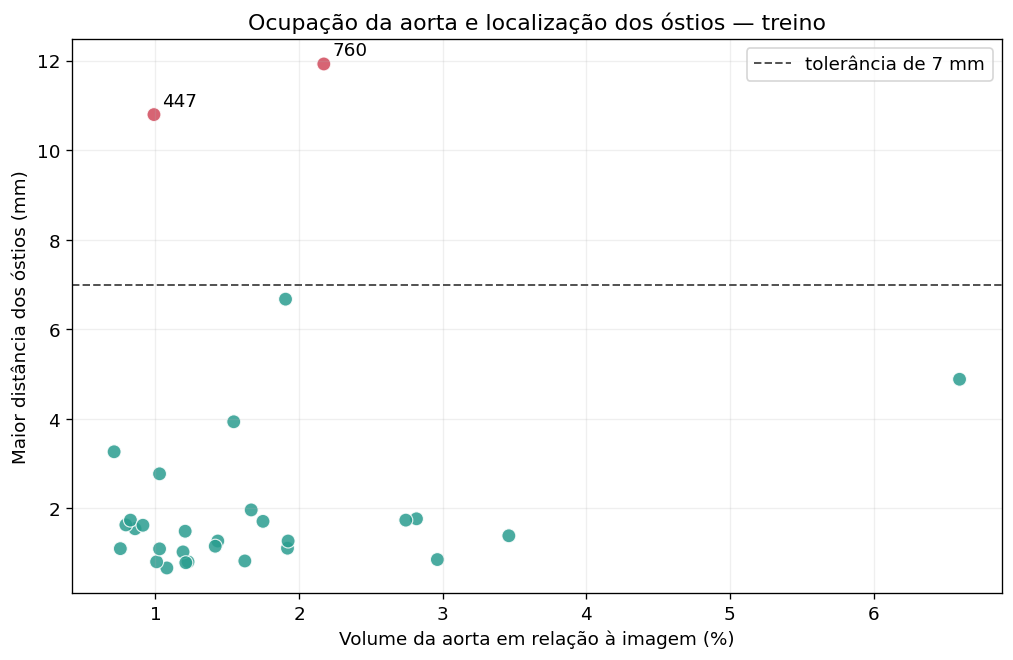

In [ ]:
plot_ostia_relationship(train_df, "treino")

Validação


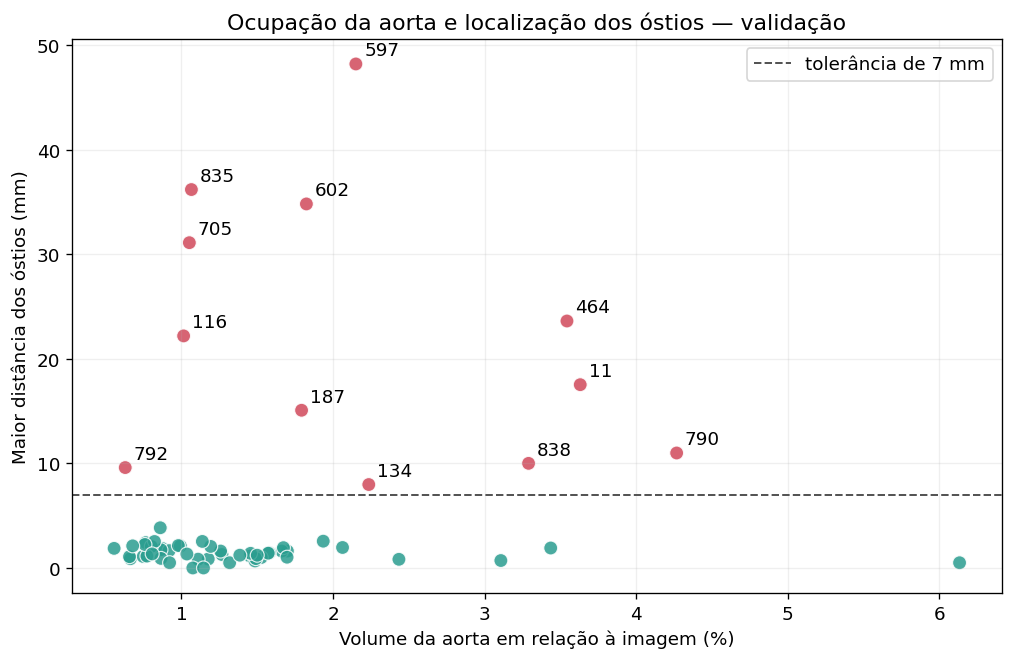

In [ ]:
plot_ostia_relationship(val_df, "validação")

## 3. Qualidade visual da aorta

Cada subseção responde a uma pergunta específica e apresenta treino e validação em células consecutivas.

### 3.1. Qualidade visual versus desfecho dos óstios

In [10]:
print("Treino")
train_quality_vs_ostia = build_quality_crosstab(train_df)
display(train_quality_vs_ostia)

Treino


ostia_outcome,falha,sucesso,All
qualidade_visual_aorta,,,
boa,1,22,23
ruim,1,6,7
All,2,28,30


In [11]:
print("Validação")
val_quality_vs_ostia = build_quality_crosstab(val_df)
display(val_quality_vs_ostia)

Validação


ostia_outcome,falha,sucesso,All
qualidade_visual_aorta,,,
boa,4,41,45
ruim,8,7,15
All,12,48,60


### 3.2. Resumo por qualidade visual

In [12]:
print("Treino")
train_visual_summary = build_visual_summary(train_df)
display(train_visual_summary.round(3))

Treino


,visual_aorta_quality,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,voxels_por_fatia_mediana,volume_percentual_medio,volume_percentual_mediano,dice_arterial_medio
0,boa,23,219420.522,208643.0,116.565,1843.253,1657.727,1.267,1.192,0.634
1,ruim,7,475666.857,391558.0,132.571,3541.273,3299.128,3.089,2.743,0.488


In [13]:
print("Validação")
val_visual_summary = build_visual_summary(val_df)
display(val_visual_summary.round(3))

Validação


,visual_aorta_quality,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,voxels_por_fatia_mediana,volume_percentual_medio,volume_percentual_mediano,dice_arterial_medio
0,boa,45,195860.156,189686.0,112.222,1729.542,1730.966,1.154,1.076,0.623
1,ruim,15,440160.333,438805.0,134.000,3203.958,3068.566,2.725,2.435,0.483


### 3.3. Distribuição do volume e da área por fatia

Treino


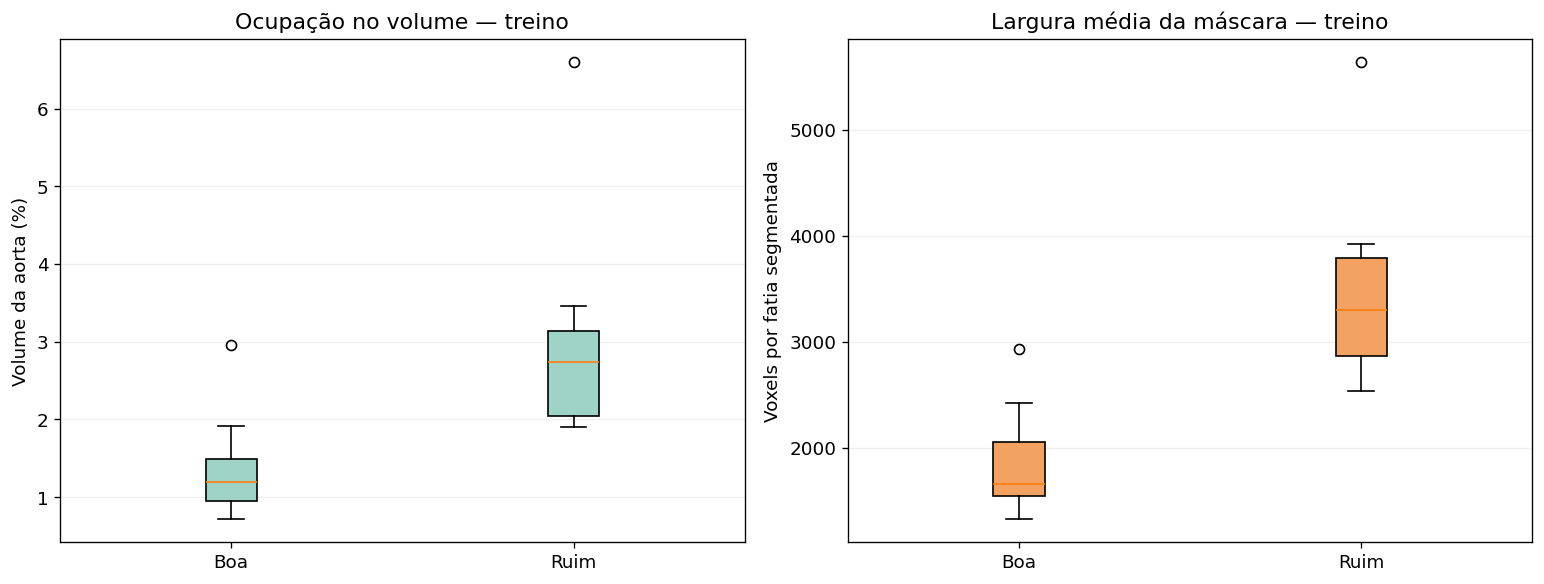

In [14]:
print("Treino")
plot_visual_quality(train_df, "treino")

Validação


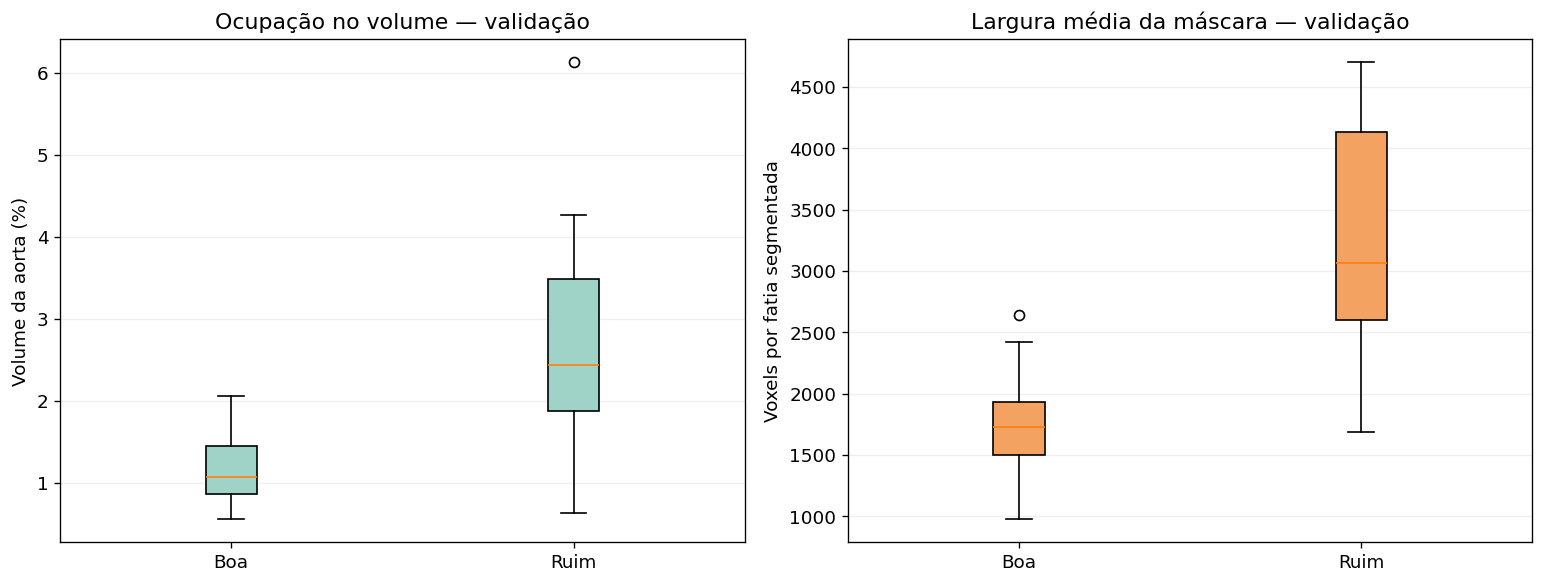

In [15]:
print("Validação")
plot_visual_quality(val_df, "validação")

### 3.4. Ocupação percentual por exame

Treino


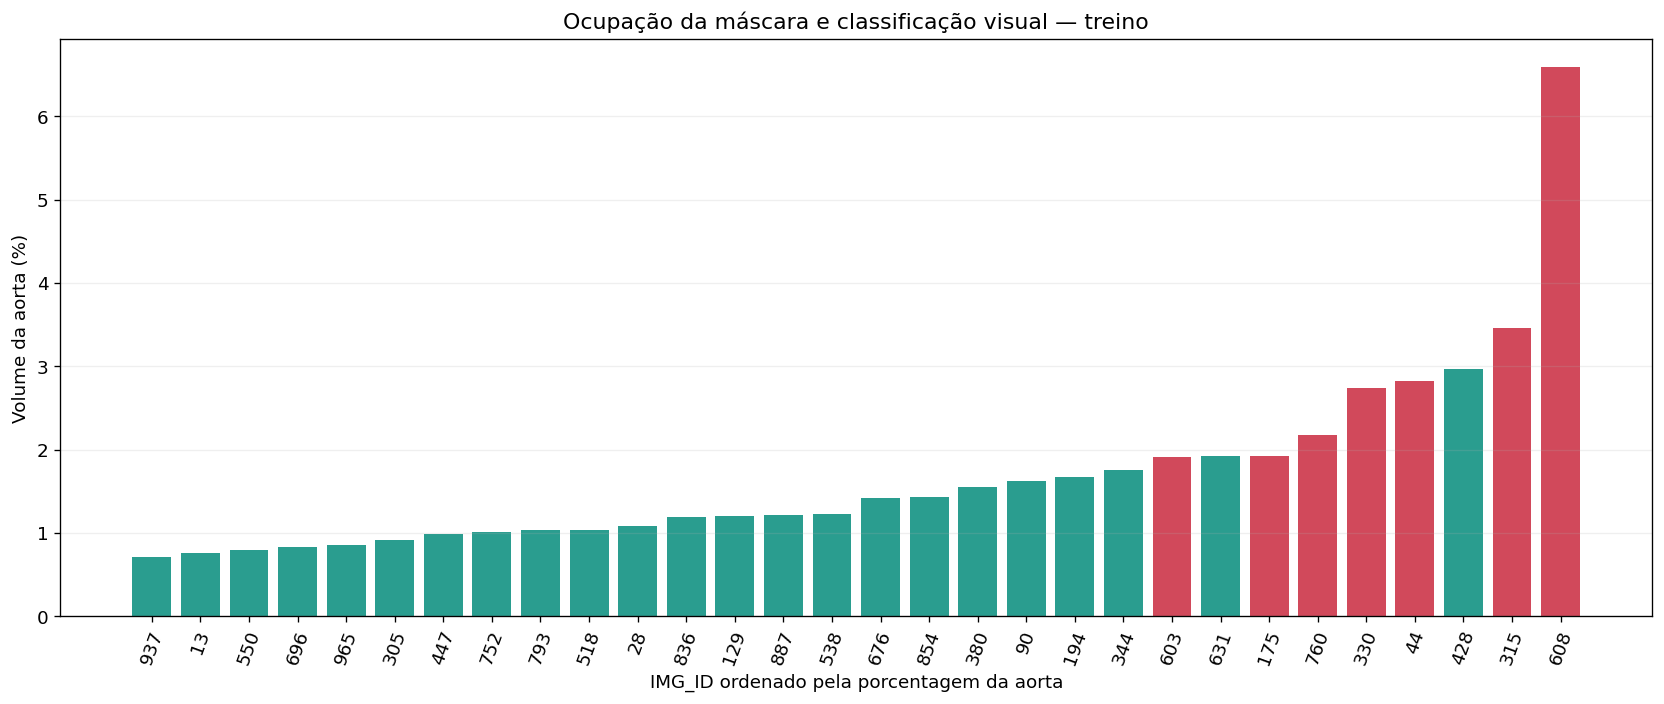

In [16]:
print("Treino")
plot_ordered_volume(train_df, "treino")

Validação


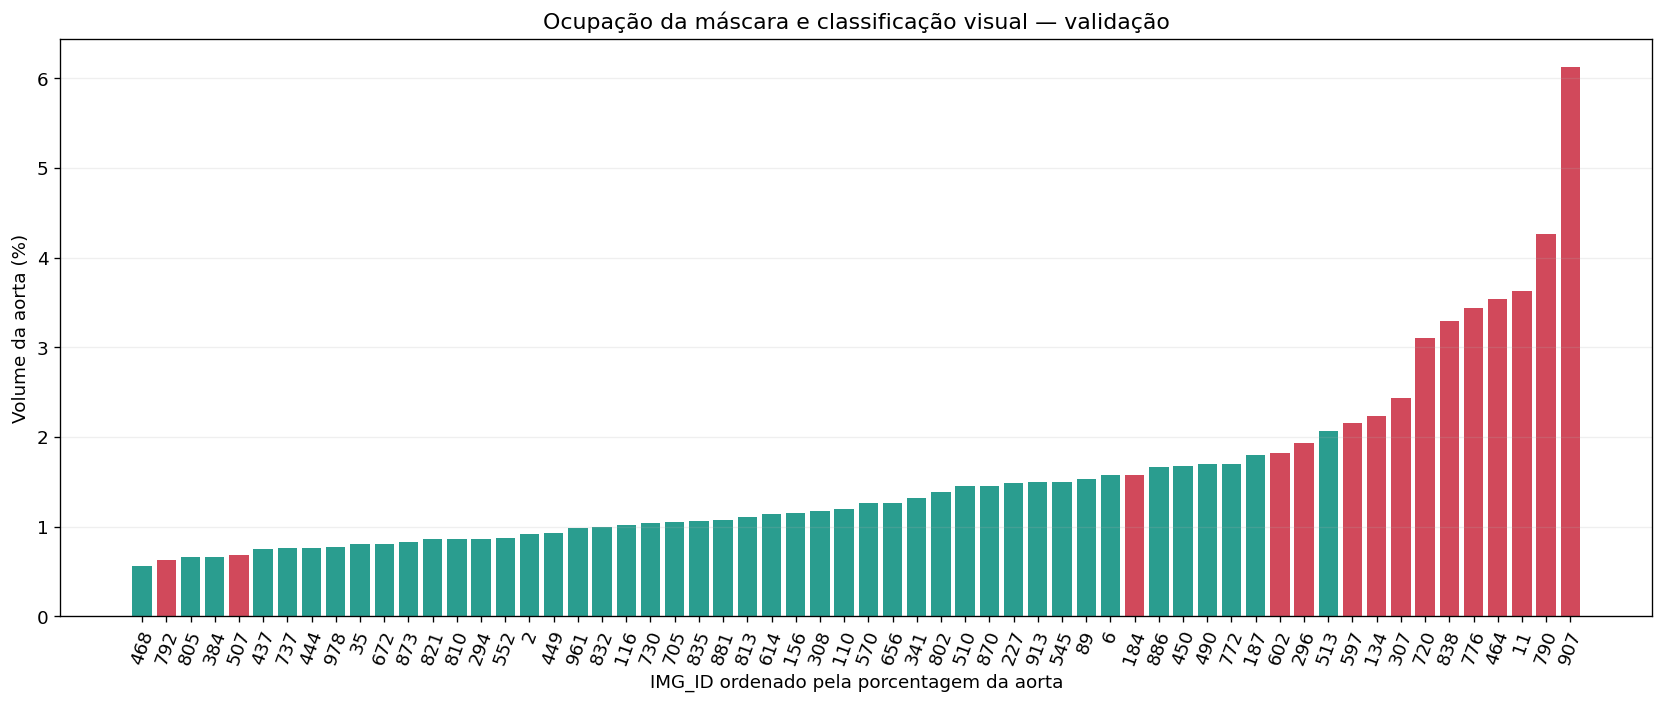

In [17]:
print("Validação")
plot_ordered_volume(val_df, "validação")

## 4. Faixa exploratória para triagem visual

O corte é ajustado somente no treino e aplicado sem recalibração na validação.

### 4.1. Desempenho do corte no treino e na validação

In [18]:
print("Treino")
train_threshold_df = find_volume_threshold(train_df)
train_best_threshold = float(
    train_threshold_df.iloc[0]["threshold_percentual"]
)
display(train_threshold_df.head(5).round(4))
print(f"Corte selecionado no treino: {train_best_threshold:.4f}%")

Treino


,threshold_percentual,acuracia,sensibilidade_aorta_ruim,especificidade_aorta_boa,acuracia_balanceada
20,1.8276,0.9333,1.0000,0.9130,0.9565
19,1.7080,0.9000,1.0000,0.8696,0.9348
18,1.6448,0.8667,1.0000,0.8261,0.9130
22,1.9218,0.9333,0.8571,0.9565,0.9068
17,1.5841,0.8333,1.0000,0.7826,0.8913


Corte selecionado no treino: 1.8276%


In [19]:
print("Validação")
val_threshold_evaluation = evaluate_volume_threshold(
    val_df,
    train_best_threshold,
)
display(val_threshold_evaluation.round(4))

Validação


,corte_do_treino_percentual,imagens,aortas_ruins_reais,aortas_sinalizadas,acuracia,sensibilidade_aorta_ruim,especificidade_aorta_boa,acuracia_balanceada
0,1.8276,60,15,12,0.9167,0.7333,0.9778,0.8556


## 5. Síntese comparativa

A tabela reúne os indicadores necessários para comparar aortas boas e ruins entre as duas coortes.

In [20]:
cohort_comparison = pd.concat(
    [
        train_df.assign(coorte="treino"),
        val_df.assign(coorte="validação"),
    ],
    ignore_index=True,
)
cohort_summary = (
    cohort_comparison.groupby(
        ["coorte", "visual_aorta_quality"], observed=True
    )
    .agg(
        imagens=("IMG_ID", "size"),
        sucesso_ostios=("ostia_success", "mean"),
        volume_percentual_medio=("aorta_volume_percentage", "mean"),
        volume_percentual_mediano=("aorta_volume_percentage", "median"),
        voxels_por_fatia_media=("aorta_voxels_per_segmented_slice", "mean"),
        dice_arterial_medio=("artery_dice", "mean"),
    )
    .reset_index()
)
display(cohort_summary.round(4))

,coorte,visual_aorta_quality,imagens,sucesso_ostios,volume_percentual_medio,volume_percentual_mediano,voxels_por_fatia_media,dice_arterial_medio
0,treino,boa,23,0.9565,1.2675,1.1922,1843.2532,0.6335
1,treino,ruim,7,0.8571,3.0891,2.7435,3541.2730,0.4883
2,validação,boa,45,0.9111,1.1544,1.0756,1729.5421,0.6234
3,validação,ruim,15,0.4667,2.7251,2.4348,3203.9578,0.4833


## Conclusão

A organização por métrica permite comparar treino e validação imediatamente. A seção redundante de aortas confirmadas foi removida, pois seus indicadores já estão disponíveis no resumo por qualidade visual e no cruzamento com o desfecho dos óstios.

In [21]:
train_good = train_df.loc[train_df["visual_aorta_quality"].eq("boa")]
train_bad = train_df.loc[train_df["visual_aorta_quality"].eq("ruim")]
val_good = val_df.loc[val_df["visual_aorta_quality"].eq("boa")]
val_bad = val_df.loc[val_df["visual_aorta_quality"].eq("ruim")]

print("Síntese da análise:")
print(
    f"- Treino: {len(train_good)}/{len(train_df)} aortas boas "
    f"({len(train_good) / len(train_df):.1%})."
)
print(
    f"- Validação: {len(val_good)}/{len(val_df)} aortas boas "
    f"({len(val_good) / len(val_df):.1%})."
)
print(
    f"- Volume médio treino — boas: {train_good['aorta_volume_percentage'].mean():.2f}%; "
    f"ruins: {train_bad['aorta_volume_percentage'].mean():.2f}%."
)
print(
    f"- Volume médio validação — boas: {val_good['aorta_volume_percentage'].mean():.2f}%; "
    f"ruins: {val_bad['aorta_volume_percentage'].mean():.2f}%."
)
print(
    f"- Corte aprendido no treino: {train_best_threshold:.2f}%; "
    f"acurácia balanceada na validação: "
    f"{val_threshold_evaluation.iloc[0]['acuracia_balanceada']:.1%}."
)
print(
    f"- Sucesso dos óstios nas aortas boas da validação: "
    f"{val_good['ostia_success'].mean():.1%}."
)
print("- O exame 187 foi mantido como bom, com ressalva de subsegmentação leve.")

Síntese da análise:
- Treino: 23/30 aortas boas (76.7%).
- Validação: 45/60 aortas boas (75.0%).
- Volume médio treino — boas: 1.27%; ruins: 3.09%.
- Volume médio validação — boas: 1.15%; ruins: 2.73%.
- Corte aprendido no treino: 1.83%; acurácia balanceada na validação: 85.6%.
- Sucesso dos óstios nas aortas boas da validação: 91.1%.
- O exame 187 foi mantido como bom, com ressalva de subsegmentação leve.
